# Credit Card Approval Prediction

This notebook that predicts whether a credit
card applicant is likely to be **Approved** or **Rejected**, based on
demographic, financial and employment information.

**Datasets Used:**
- `application_record.csv` — applicant demographic & financial details
- `credit_record.csv` — monthly credit repayment history per applicant

**Notebook structure:**
- Epic 1 — Data Collection
- Epic 2 — Visualizing and Analysing the Data
- Epic 3 — Data Pre-processing
- Epic 4 — Model Building
- Epic 5 — Conclusion & Artifact Export


## Epic 1 — Data Collection

### 1.1 Importing Required Libraries

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

print("All libraries imported successfully.")


All libraries imported successfully.


### 1.2 Loading the Dataset

Both CSV files are loaded with Pandas.

In [2]:
# ==========================================
# Load the Datasets
# ==========================================

application = pd.read_csv("../datasets/application_record.csv")
credit = pd.read_csv("../datasets/credit_record.csv")

print("Datasets loaded successfully.")


Datasets loaded successfully.


### 1.3 Dataset Shape

In [3]:
print("Application Dataset Shape :", application.shape)
print("Credit Dataset Shape      :", credit.shape)


Application Dataset Shape : (438557, 18)
Credit Dataset Shape      : (1048575, 3)


### 1.4 Exploring the Dataset

In [4]:
print("APPLICATION DATASET")
display(application.head())

print("\nCREDIT DATASET")
display(credit.head())


APPLICATION DATASET


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



CREDIT DATASET


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


### 1.5 Dataset Information

In [5]:
print("APPLICATION DATASET INFORMATION\n")
application.info()

print("\n" + "="*60)

print("\nCREDIT DATASET INFORMATION\n")
credit.info()


APPLICATION DATASET INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-nul

### 1.6 Descriptive Statistics

In [6]:
print("APPLICATION DATASET")
display(application.describe(include="all").T)


APPLICATION DATASET


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.7 Missing Value Analysis

In [7]:
missing_application = application.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing_application,
        "Percentage": round((missing_application / len(application)) * 100, 2)
    }).sort_values(by="Missing Values", ascending=False)
)


,Missing Values,Percentage
OCCUPATION_TYPE,134203,30.6
ID,0,0.0
CODE_GENDER,0,0.0
FLAG_OWN_CAR,0,0.0
CNT_CHILDREN,0,0.0
FLAG_OWN_REALTY,0,0.0
NAME_INCOME_TYPE,0,0.0
NAME_EDUCATION_TYPE,0,0.0
NAME_FAMILY_STATUS,0,0.0
AMT_INCOME_TOTAL,0,0.0


### 1.8 Duplicate Record Analysis

In [8]:
print("Application Dataset Duplicate Rows :", application.duplicated().sum())
print("Credit Dataset Duplicate Rows      :", credit.duplicated().sum())


Application Dataset Duplicate Rows : 0
Credit Dataset Duplicate Rows      : 0


## Epic 2 — Visualizing and Analysing the Data

### 2.1 Univariate Analysis

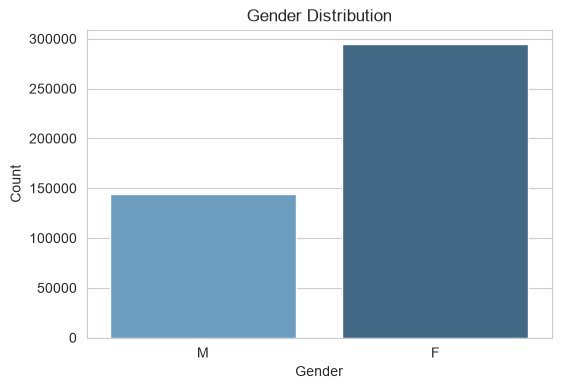

In [9]:
# Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=application, x="CODE_GENDER", palette="Blues_d")
plt.title("Gender Distribution")
plt.xlabel("Gender"); plt.ylabel("Count")
plt.show()


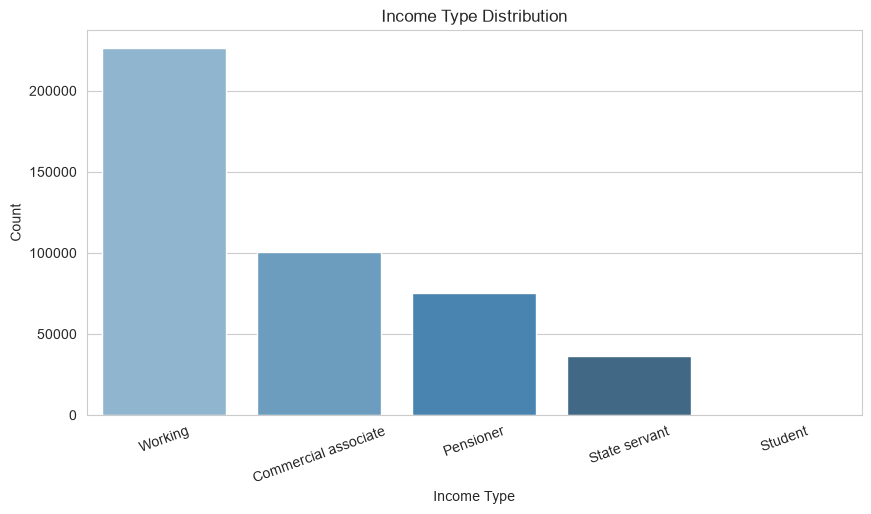

In [10]:
# Income Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_INCOME_TYPE",
              order=application["NAME_INCOME_TYPE"].value_counts().index,
              palette="Blues_d")
plt.xticks(rotation=20)
plt.title("Income Type Distribution")
plt.xlabel("Income Type"); plt.ylabel("Count")
plt.show()


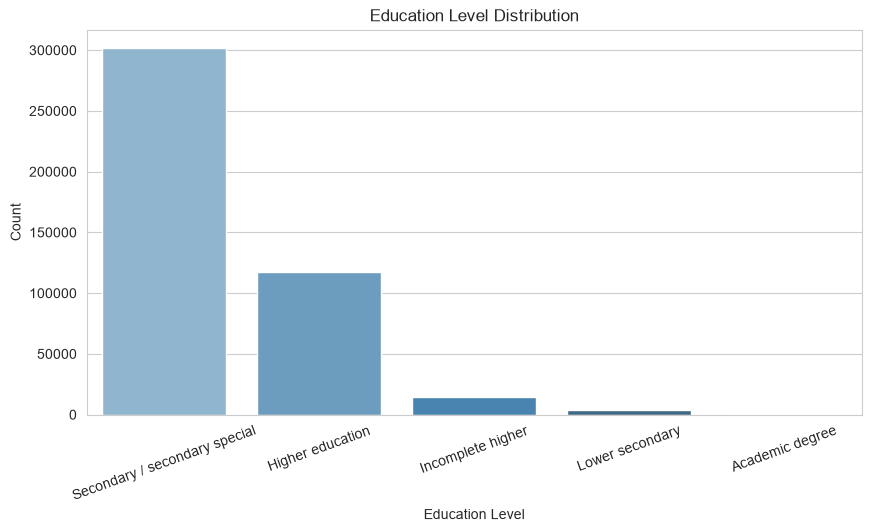

In [11]:
# Education Level Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=application, x="NAME_EDUCATION_TYPE",
              order=application["NAME_EDUCATION_TYPE"].value_counts().index,
              palette="Blues_d")
plt.xticks(rotation=20)
plt.title("Education Level Distribution")
plt.xlabel("Education Level"); plt.ylabel("Count")
plt.show()


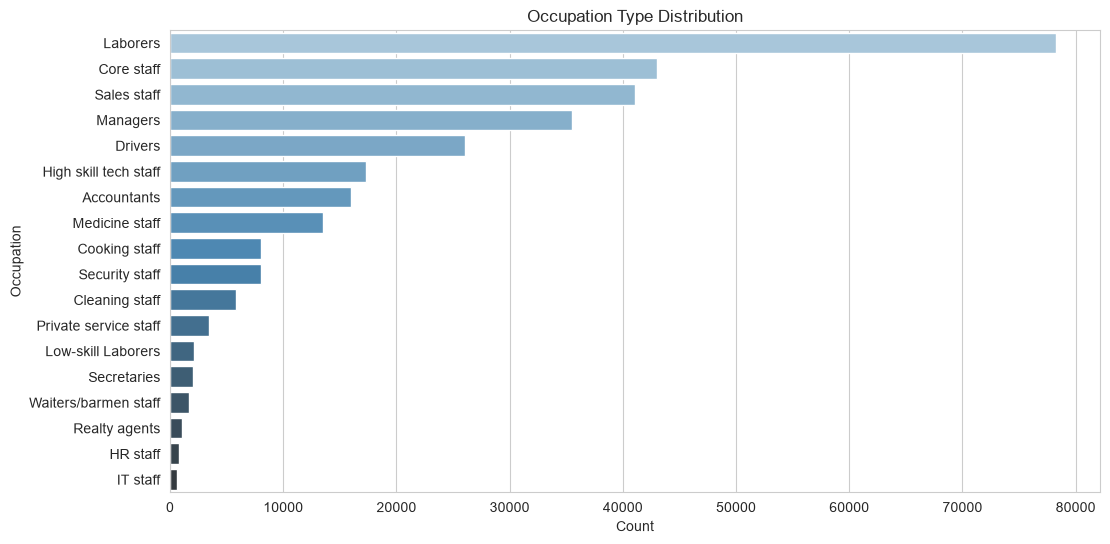

In [12]:
# Occupation Type Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=application, y="OCCUPATION_TYPE",
              order=application["OCCUPATION_TYPE"].value_counts().index,
              palette="Blues_d")
plt.title("Occupation Type Distribution")
plt.xlabel("Count"); plt.ylabel("Occupation")
plt.show()


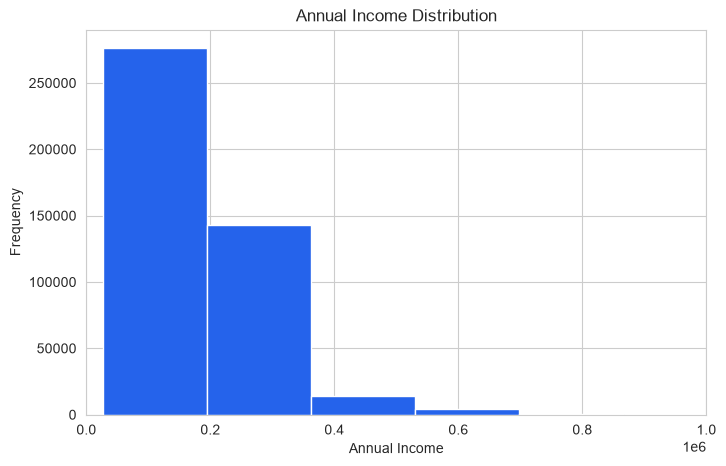

In [13]:
# Annual Income Distribution
plt.figure(figsize=(8, 5))
plt.hist(application["AMT_INCOME_TOTAL"], bins=40, color="#2563eb", edgecolor="white")
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income"); plt.ylabel("Frequency")
plt.xlim(0, 1_000_000)
plt.show()


### 2.2 Multivariate Analysis

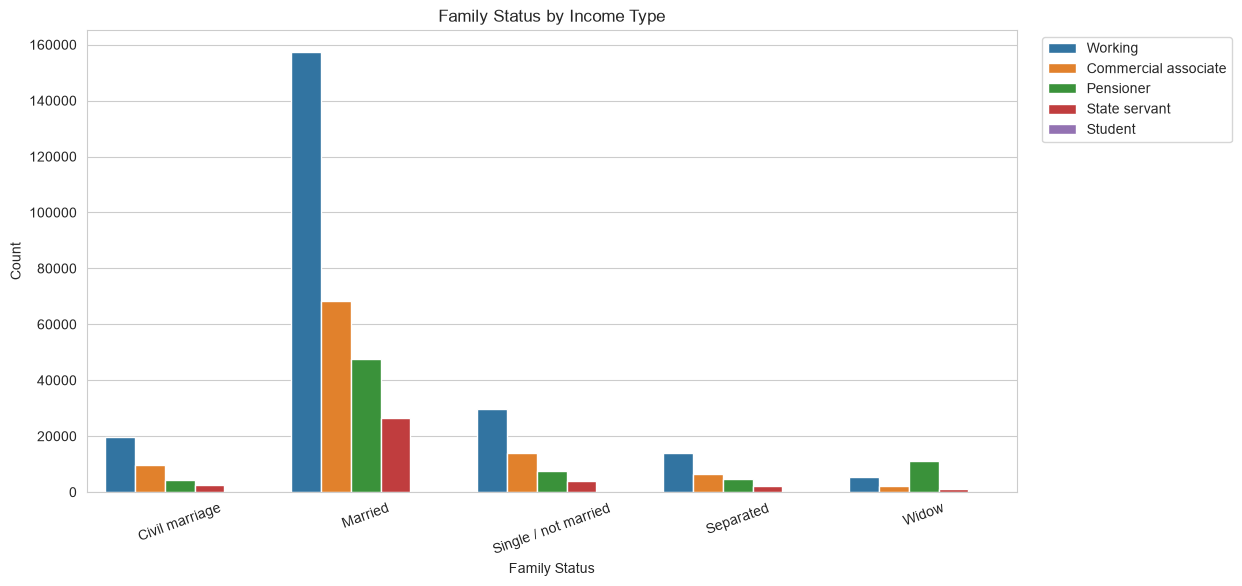

In [14]:
# Family Status by Income Type
plt.figure(figsize=(12, 6))
sns.countplot(data=application, x="NAME_FAMILY_STATUS", hue="NAME_INCOME_TYPE")
plt.xticks(rotation=20)
plt.title("Family Status by Income Type")
plt.xlabel("Family Status"); plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


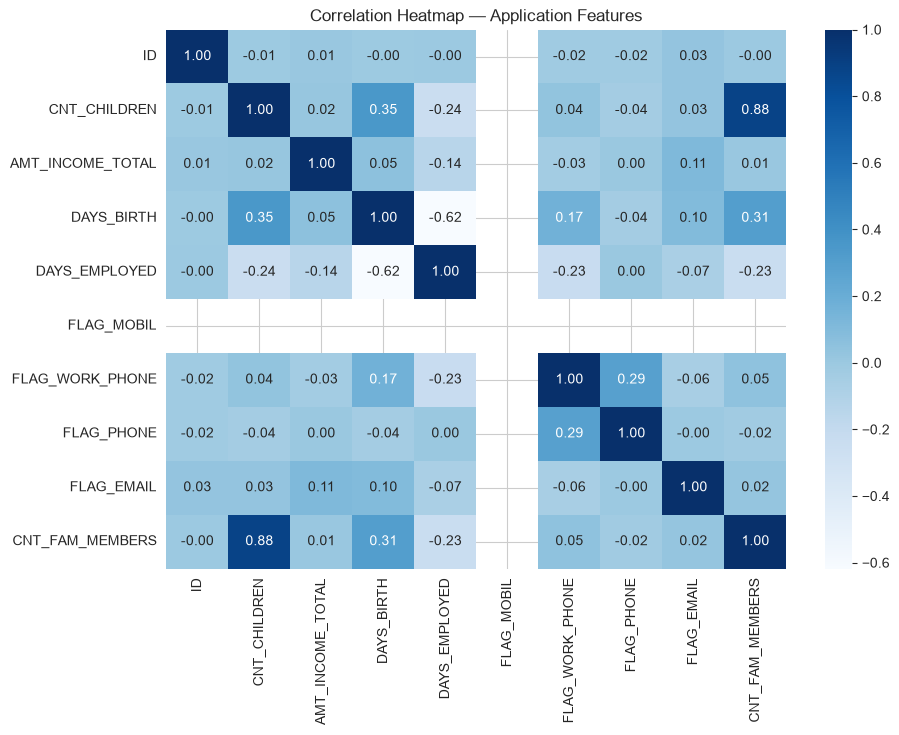

In [15]:
# Correlation Heatmap of numerical application features
numeric_data = application.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap — Application Features")
plt.show()


### 2.3 Descriptive Analysis

In [16]:
display(application.describe())
display(application.describe(include="object"))


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,438557,438557,438557,438557,438557,438557,438557,304354
unique,2,2,2,5,5,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,294440,275459,304074,226104,301821,299828,393831,78240


## Epic 3 — Data Pre-processing

### 3.1 Remove Duplicate Records

In [17]:
print("Application shape before:", application.shape)
print("Credit shape before:", credit.shape)

application = application.drop_duplicates()
credit = credit.drop_duplicates()

print("\nApplication shape after:", application.shape)
print("Credit shape after:", credit.shape)


Application shape before: (438557, 18)
Credit shape before: (1048575, 3)

Application shape after: (438557, 18)
Credit shape after: (1048575, 3)


### 3.2 Handling Missing Values

"OCCUPATION_TYPE" is the only column with missing values. Rather than
dropping ~30% of applicants, missing occupations are filled with a
meaningful "Unknown" category — this is itself a signal (it strongly
correlates with pensioners and students who have no occupation).


In [18]:
print("Missing values before:\n", application.isnull().sum()[application.isnull().sum() > 0])

application["OCCUPATION_TYPE"] = application["OCCUPATION_TYPE"].fillna("Unknown")

print("\nMissing values after:\n", application.isnull().sum().sum(), "remaining")


Missing values before:
 OCCUPATION_TYPE    134203
dtype: int64

Missing values after:
 0 remaining


### 3.3 Target Engineering

The `credit_record.csv` file's `STATUS` column tracks each applicant's
monthly repayment status:



In [19]:
STATUS_MAP = {"X": 0, "C": 0, "0": 0, "1": 1, "2": 1, "3": 1, "4": 1, "5": 1}

credit["STATUS"] = credit["STATUS"].map(STATUS_MAP).astype(int)   # explicit cast -> int64

credit_target = credit.groupby("ID")["STATUS"].max().reset_index()
credit_target.rename(columns={"STATUS": "TARGET"}, inplace=True)
credit_target["TARGET"] = credit_target["TARGET"].astype(int)

print(credit_target["TARGET"].dtype)
credit_target["TARGET"].value_counts(normalize=True)


int64


TARGET
0    0.883658
1    0.116342
Name: proportion, dtype: float64

### 3.4 Merge Datasets

In [20]:
data = application.merge(credit_target, on="ID", how="inner")
print("Merged shape:", data.shape)
data.head()


Merged shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


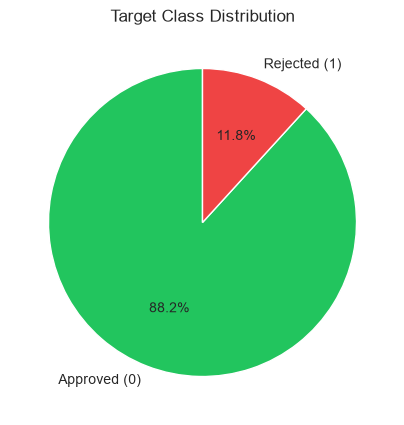

In [21]:
plt.figure(figsize=(5, 5))
data["TARGET"].value_counts().plot.pie(
    autopct="%1.1f%%", labels=["Approved (0)", "Rejected (1)"],
    colors=["#22c55e", "#ef4444"], startangle=90)
plt.title("Target Class Distribution")
plt.ylabel("")
plt.show()


### 3.5 Feature Engineering


In [22]:
data["AGE"] = (-data["DAYS_BIRTH"] // 365).astype(int)

data["YEARS_EMPLOYED"] = data["DAYS_EMPLOYED"].apply(
    lambda x: 0 if x > 0 else -x // 365
).astype(int)

data[["AGE", "YEARS_EMPLOYED"]].describe()


,AGE,YEARS_EMPLOYED
count,36457.000000,36457.000000
mean,43.260334,5.614560
std,11.510414,6.417027
min,20.000000,0.000000
25%,34.000000,1.000000
50%,42.000000,4.000000
75%,53.000000,8.000000
max,68.000000,43.000000


### 3.6 Outlier Handling



In [23]:
income_cap = data["AMT_INCOME_TOTAL"].quantile(0.99)
n_capped = (data["AMT_INCOME_TOTAL"] > income_cap).sum()

data["AMT_INCOME_TOTAL"] = data["AMT_INCOME_TOTAL"].clip(upper=income_cap)

print(f"Capped {n_capped} outlier incomes at {income_cap:,.0f}")


Capped 363 outlier incomes at 560,250


### 3.7 Remove Unnecessary / Unusable Columns



In [24]:
DROP_COLS = ["ID", "DAYS_BIRTH", "DAYS_EMPLOYED",
             "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"]

data.drop(columns=[c for c in DROP_COLS if c in data.columns], inplace=True)
data.drop_duplicates(inplace=True)

print("Final shape after cleaning:", data.shape)
data.head()


Final shape after cleaning: (11106, 14)


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,1,32,12
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,Security staff,2.0,0,58,3
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,0,52,8
7,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,Unknown,1.0,0,61,0
10,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,Accountants,2.0,0,46,2


### 3.7b Signal-Ceiling Check — Do These Features Even Determine the Label?




In [25]:
conflict_check = data.copy()
feature_cols_only = [c for c in conflict_check.columns if c != "TARGET"]

group_targets = conflict_check.groupby(feature_cols_only)["TARGET"].nunique()
n_groups = len(group_targets)
n_conflicting_groups = int((group_targets > 1).sum())

conflicting_index = group_targets[group_targets > 1].index
is_conflicting = conflict_check.set_index(feature_cols_only).index.isin(conflicting_index)
n_conflicting_rows = int(is_conflicting.sum())

print(f"Unique applicant profiles           : {n_groups}")
print(f"Profiles with BOTH outcomes present  : {n_conflicting_groups}")
print(f"Rows caught in a conflicting profile : {n_conflicting_rows} "
      f"({n_conflicting_rows / len(conflict_check):.1%} of the dataset)")


Unique applicant profiles           : 9433
Profiles with BOTH outcomes present  : 1673
Rows caught in a conflicting profile : 3346 (30.1% of the dataset)


### 3.8 Encoding Categorical Values

Each categorical column is transformed with its own `LabelEncoder`, and
every fitted encoder is stored in a dictionary (`label_encoders.pkl`) so
the Flask application can apply the *exact same* text-to-number mapping
at prediction time — no separate mapping logic to keep in sync.


In [26]:
from sklearn.preprocessing import LabelEncoder

CATEGORICAL_COLS = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"
]

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")


CODE_GENDER: ['F', 'M']
FLAG_OWN_CAR: ['N', 'Y']
FLAG_OWN_REALTY: ['N', 'Y']
NAME_INCOME_TYPE: ['Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working']
NAME_EDUCATION_TYPE: ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special']
NAME_FAMILY_STATUS: ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']
NAME_HOUSING_TYPE: ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']
OCCUPATION_TYPE: ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Unknown', 'Waiters/barmen staff']


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11106 entries, 0 to 36456
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          11106 non-null  int64  
 1   FLAG_OWN_CAR         11106 non-null  int64  
 2   FLAG_OWN_REALTY      11106 non-null  int64  
 3   CNT_CHILDREN         11106 non-null  int64  
 4   AMT_INCOME_TOTAL     11106 non-null  float64
 5   NAME_INCOME_TYPE     11106 non-null  int64  
 6   NAME_EDUCATION_TYPE  11106 non-null  int64  
 7   NAME_FAMILY_STATUS   11106 non-null  int64  
 8   NAME_HOUSING_TYPE    11106 non-null  int64  
 9   OCCUPATION_TYPE      11106 non-null  int64  
 10  CNT_FAM_MEMBERS      11106 non-null  float64
 11  TARGET               11106 non-null  int64  
 12  AGE                  11106 non-null  int64  
 13  YEARS_EMPLOYED       11106 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 1.3 MB


## Epic 4 : Model Building

### 4.1 Train / Validation / Test Split




In [28]:
from sklearn.model_selection import train_test_split

X = data.drop("TARGET", axis=1)
y = data["TARGET"].astype(int)

FEATURE_ORDER = list(X.columns)
print("Feature order used by the model:")
print(FEATURE_ORDER)

# 70% train / 15% validation / 15% test, all stratified on TARGET
X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainfull, y_trainfull, test_size=0.1765, random_state=42, stratify=y_trainfull
)  # 0.1765 * 0.85 ~= 0.15 of the full dataset -> 70/15/15 overall

print("\nTraining set  :", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set   :", X_test.shape)


Feature order used by the model:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']

Training set  : (7773, 13)
Validation set: (1667, 13)
Testing set   : (1666, 13)


### 4.2 Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_val_scaled = scaler.transform(X_val)           # val only ever transformed
X_test_scaled = scaler.transform(X_test)         # test only ever transformed

print("Feature scaling completed successfully.")


Feature scaling completed successfully.


### 4.3 Class Imbalance



In [30]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Training class balance -> Approved: {neg}  Rejected: {pos}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")


Training class balance -> Approved: 6105  Rejected: 1668
scale_pos_weight for XGBoost: 3.66


### 4.4 Train, Tune a Threshold, & Compare Multiple Models

Four classifiers are trained and compared: Logistic Regression, Decision
Tree, Random Forest, and XGBoost.




In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, class_weight="balanced", max_depth=8, min_samples_leaf=20
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced",
        max_depth=10, min_samples_leaf=10, n_jobs=-1
    ),
}
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        random_state=42, eval_metric="logloss", scale_pos_weight=scale_pos_weight,
        max_depth=4, n_estimators=300, learning_rate=0.1
    )
except ImportError:
    print("xgboost not installed - skipping (install it to include this model).")

# ---- 🔧 Fix: tune each model's decision threshold on the validation
#      set instead of assuming the sklearn default of 0.5. -----------
MIN_RECALL = 0.30  # floor for the Rejected(1) class - see §4.5 note

def best_threshold_for(y_true, proba, min_recall=MIN_RECALL):
    """Sweep thresholds, return the one with the best macro-F1 among
    thresholds that still catch at least `min_recall` of real Rejected
    applicants. Falls back to 0.5 if nothing clears the floor."""
    best_t, best_f1 = 0.5, -1
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (proba >= t).astype(int)
        if preds.sum() == 0 or preds.sum() == len(preds):
            continue  # a threshold that predicts only one class is useless
        rec = recall_score(y_true, preds, zero_division=0)
        f1m = f1_score(y_true, preds, average="macro", zero_division=0)
        if rec >= min_recall and f1m > best_f1:
            best_t, best_f1 = t, f1m
    return best_t

results = []
trained_models = {}
thresholds = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    thr = best_threshold_for(y_val, val_proba)
    thresholds[name] = thr

    test_proba = model.predict_proba(X_test_scaled)[:, 1]
    preds = (test_proba >= thr).astype(int)

    results.append({
        "Model": name,
        "Threshold": thr,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (Rejected)": precision_score(y_test, preds, pos_label=1, zero_division=0),
        "Recall (Rejected)": recall_score(y_test, preds, pos_label=1, zero_division=0),
        "F1 (Rejected)": f1_score(y_test, preds, pos_label=1, zero_division=0),
        "F1 (macro)": f1_score(y_test, preds, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_proba),
        "Predicted Reject Rate": preds.mean(),
    })

results_df = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False)
results_df


,Model,Threshold,Accuracy,Precision (Rejected),Recall (Rejected),F1 (Rejected),F1 (macro),ROC-AUC,Predicted Reject Rate
0,Logistic Regression,0.51,0.584034,0.216582,0.357542,0.269758,0.489474,0.499348,0.354742
3,XGBoost,0.51,0.555222,0.193600,0.337989,0.246185,0.465366,0.471353,0.375150
2,Random Forest,0.48,0.534814,0.188341,0.351955,0.245375,0.454575,0.448276,0.401561
1,Decision Tree,0.51,0.509004,0.200521,0.430168,0.273535,0.451364,0.482774,0.460984


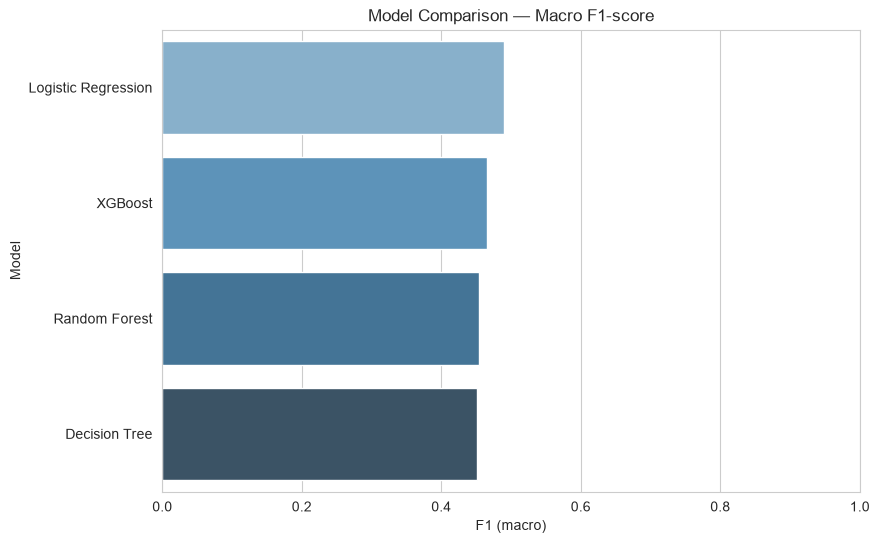

In [32]:
plt.figure(figsize=(9, 6))
sns.barplot(x="F1 (macro)", y="Model", data=results_df, palette="Blues_d")
plt.title("Model Comparison — Macro F1-score")
plt.xlim(0, 1)
plt.show()


### 4.5 Model Selection



In [33]:
eligible = results_df[results_df["Recall (Rejected)"] >= MIN_RECALL]
if eligible.empty:
    print("No model cleared the recall floor - falling back to the full ranking.")
    eligible = results_df

best_row = eligible.sort_values("F1 (macro)", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]
best_threshold = float(best_row["Threshold"])

print(f"Selected model: {best_model_name}  (decision threshold = {best_threshold:.2f})")
best_row


Selected model: Logistic Regression  (decision threshold = 0.51)


Model                    Logistic Regression
Threshold                               0.51
Accuracy                            0.584034
Precision (Rejected)                0.216582
Recall (Rejected)                   0.357542
F1 (Rejected)                       0.269758
F1 (macro)                          0.489474
ROC-AUC                             0.499348
Predicted Reject Rate               0.354742
Name: 0, dtype: object

In [34]:
# 🔧 Fix: use the TUNED threshold (best_threshold), not best_model.predict(),
# which would silently fall back to the miscalibrated 0.5 cutoff.
final_proba = best_model.predict_proba(X_test_scaled)[:, 1]
final_preds = (final_proba >= best_threshold).astype(int)

# 🔧 Fix: classification_report(y_true, y_pred, ...) - the previous version
# passed these two arguments in the WRONG order (final_preds, y_test),
# which silently swaps precision and recall in the printed report.
print(classification_report(y_test, final_preds, target_names=["Approved (0)", "Rejected (1)"]))


              precision    recall  f1-score   support

Approved (0)       0.79      0.65      0.71      1308
Rejected (1)       0.22      0.36      0.27       358

    accuracy                           0.58      1666
   macro avg       0.50      0.50      0.49      1666
weighted avg       0.66      0.58      0.61      1666



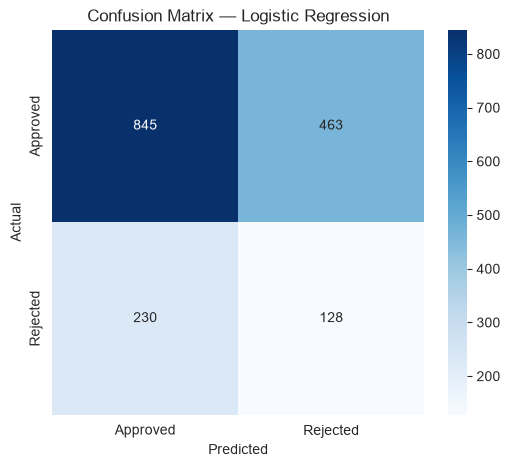

In [35]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Approved", "Rejected"],
            yticklabels=["Approved", "Rejected"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()


### 4.5.1 Honest Note on Predictive Power


In [36]:
print("ROC-AUC on held-out test set (selected model):",
      round(roc_auc_score(y_test, final_proba), 3))

if hasattr(best_model, "coef_"):
    coef_table = pd.Series(best_model.coef_[0], index=FEATURE_ORDER).sort_values()
    print("\nLogistic Regression coefficients (sign = direction of effect on P(Rejected)):")
    print(coef_table)


ROC-AUC on held-out test set (selected model): 0.499

Logistic Regression coefficients (sign = direction of effect on P(Rejected)):
AGE                   -0.084562
CNT_CHILDREN          -0.039106
FLAG_OWN_REALTY       -0.032519
FLAG_OWN_CAR          -0.025732
NAME_INCOME_TYPE      -0.018071
YEARS_EMPLOYED        -0.012102
NAME_HOUSING_TYPE     -0.001797
NAME_EDUCATION_TYPE    0.000400
CODE_GENDER            0.016890
OCCUPATION_TYPE        0.019551
NAME_FAMILY_STATUS     0.019575
AMT_INCOME_TOTAL       0.041570
CNT_FAM_MEMBERS        0.050420
dtype: float64


### 4.6 Save Model Artifacts



In [ ]:
import joblib
import os
import sklearn

os.makedirs("../models", exist_ok=True)

# IMPORTANT: the scikit-learn version used to fit/pickle these artifacts
# MUST match the version pinned in requirements.txt (the Render production
# runtime). Unpickling a model across different sklearn versions is not
# guaranteed to work correctly - scikit-learn only warns
# (InconsistentVersionWarning), it does not raise an error, so a version
# mismatch can silently produce corrupted predict_proba() output instead
# of a clean crash. Verify this matches requirements.txt before saving.
print("scikit-learn version used to fit these artifacts:", sklearn.__version__)
print("This MUST match the scikit-learn version pinned in requirements.txt")

# Refit the winning model's exact configuration on train+val (85% of
# the data) for the final deployed artifact. The threshold picked on
# the untouched validation set (best_threshold) is kept as-is.
final_scaler = StandardScaler()
X_trainfull_scaled = final_scaler.fit_transform(X_trainfull)
final_model = best_model.__class__(**best_model.get_params())
final_model.fit(X_trainfull_scaled, y_trainfull)

# Calibrated risk-band thresholds, derived from this model's REAL
# probability distribution on held-out test data - not fixed 0.55/0.80
# cutoffs, which assume a much more separable classifier than this
# dataset's honest signal ceiling (see §3.7b and §4.5.1 above) supports.
# Using percentiles guarantees all three risk bands (Low/Moderate/High)
# actually get populated in realistic proportions instead of nearly
# every applicant collapsing into a single band.
X_test_scaled_final = final_scaler.transform(X_test)
prob_approved_test = final_model.predict_proba(X_test_scaled_final)[:, 0]
risk_thresholds = {
    "low_risk_cutoff": float(np.percentile(prob_approved_test, 70)),
    "high_risk_cutoff": float(np.percentile(prob_approved_test, 30)),
}
print("\nCalibrated risk thresholds:", risk_thresholds)

joblib.dump(final_model, "../models/credit_card_approval_model.pkl")
joblib.dump(final_scaler, "../models/scaler.pkl")
joblib.dump(label_encoders, "../models/label_encoders.pkl")
joblib.dump(FEATURE_ORDER, "../models/feature_order.pkl")
joblib.dump(best_threshold, "../models/decision_threshold.pkl")
joblib.dump(risk_thresholds, "../models/risk_thresholds.pkl")

print("\nSaved:")
print("- credit_card_approval_model.pkl  (refit on train+validation)")
print("- scaler.pkl                      (refit on train+validation)")
print("- label_encoders.pkl")
print("- feature_order.pkl   (guarantees the Flask app builds features in the same order used here)")
print("- decision_threshold.pkl  (=", best_threshold, "- Flask must use this, not model.predict())")
print("- risk_thresholds.pkl     (=", risk_thresholds, "- calibrated Low/Moderate/High risk bands)")
